In [ ]:
import numpy as np
import random as rd
import serial
from matplotlib import pyplot as plt

In [ ]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:d}',end=' ')
    print()

In [ ]:
Din = 8 #Diminsão das matrizes
DigitosPorSimbolo = 1 #digitos por elementos das matrizes
Ain = np.zeros((Din,Din),dtype=int)
Bin = np.zeros((Din,Din),dtype=int)
for i in range(Din):
  for j in range(Din):
    Ain[i][j] = rd.randint(0*10**(DigitosPorSimbolo-1),1*10**(DigitosPorSimbolo-1))
    Bin[i][j] = rd.randint(0*10**(DigitosPorSimbolo-1),1*10**(DigitosPorSimbolo-1))


In [ ]:
Ain@Bin

array([[1, 2, 1, 1, 1, 1, 1, 0],
       [2, 3, 3, 3, 3, 4, 3, 3],
       [3, 3, 3, 2, 5, 3, 3, 3],
       [1, 4, 2, 1, 2, 1, 2, 2],
       [2, 3, 2, 2, 2, 2, 2, 2],
       [3, 3, 2, 1, 4, 2, 2, 2],
       [2, 3, 2, 2, 3, 3, 2, 2],
       [0, 1, 0, 1, 0, 0, 0, 0]])

In [ ]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((2*X1.shape[0]-1,X1.shape[0]),dtype=int)
  Y2 = np.zeros((2*X2.shape[0]-1,X2.shape[0]),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i+j][j] = X1[i][j]
        Y2[i+j][j] = X2[j][i] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]

Ms = shiftMatrixSystolic(Ain,Bin)
print_matrix(Ms[0])
print()
print_matrix(Ms[1])

0 0 0 0 0 0 0 0 
1 0 0 0 0 0 0 0 
1 0 0 0 0 0 0 0 
0 1 1 0 0 0 0 0 
1 1 0 1 1 0 0 0 
0 0 1 1 1 0 0 0 
0 1 1 0 0 0 1 0 
0 0 0 0 1 1 0 0 
0 0 0 0 1 1 0 1 
0 0 0 1 0 1 0 1 
0 0 0 0 1 1 0 0 
0 0 0 0 1 0 1 0 
0 0 0 0 0 0 1 1 
0 0 0 0 0 0 0 1 
0 0 0 0 0 0 0 0 

1 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 
1 1 0 0 0 0 0 0 
1 1 1 0 0 0 0 0 
1 0 1 1 0 0 0 0 
1 1 0 1 1 1 0 0 
1 0 0 0 0 1 1 0 
0 1 1 1 1 0 1 1 
0 0 1 1 0 0 1 0 
0 0 1 1 0 1 0 0 
0 0 0 1 0 0 1 1 
0 0 0 0 0 0 1 1 
0 0 0 0 0 1 1 1 
0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 1 


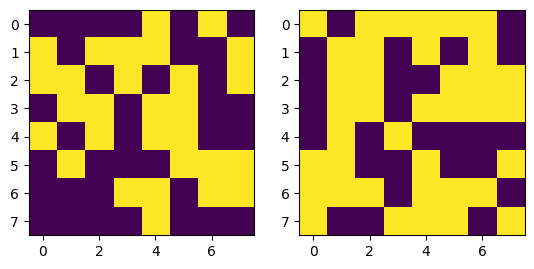

In [ ]:
plt.subplot(1,2,1)
plt.imshow(Ain)
plt.subplot(1,2,2)
plt.imshow(Bin)
plt.show()


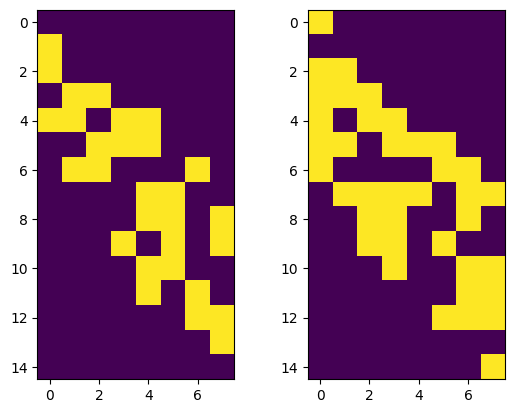

In [ ]:
plt.subplot(1,2,1)
plt.imshow(Ms[0])
plt.subplot(1,2,2)#
plt.imshow(Ms[1])
plt.show()

In [ ]:
s = serial.Serial()

s.port = "/dev/ttyUSB1"
s.baudrate = 115200
s.bytesize = 8
s.open()
i = 1
Fs = 60
t=np.linspace(0,10,1000)
while(True):
    s.write(bytearray([int(i)]))